<a href="https://colab.research.google.com/github/abhistacodes/colab-notebooks/blob/miss/PRImA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import torch
import torch.nn as nn
import os
from pathlib import Path
import os
import shutil
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [3]:
#Mount Drive to access dataset
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
#setting the dataset path
DATASET_ZIP = Path(
    "/content/drive/MyDrive/Datasets/PRImA_Layout_Analysis_Dataset.zip"
)

WORK_DIR = Path("/content/PRImA_project")
WORK_DIR.mkdir(parents=True, exist_ok=True)

print(DATASET_ZIP)
print("Exists:", DATASET_ZIP.exists())

/content/drive/MyDrive/Datasets/PRImA_Layout_Analysis_Dataset.zip
Exists: True


In [5]:
#Copy the ZIP to the Colab machine

!cp "/content/drive/MyDrive/Datasets/PRImA_Layout_Analysis_Dataset.zip" \
    "/content/PRImA_project/"

In [6]:
#check copied zip file size in colab machine

#from pathlib import Path

zip_path = Path(
    "/content/PRImA_project/PRImA_Layout_Analysis_Dataset.zip"
)

print("Exists:", zip_path.exists())

if zip_path.exists():
    print("Size:", zip_path.stat().st_size, "bytes")
    print("Size:", zip_path.stat().st_size / (1024**3), "GB")

Exists: True
Size: 3253483294 bytes
Size: 3.030042437836528 GB


In [7]:
#test the contents of zip
!unzip -t "/content/PRImA_project/PRImA_Layout_Analysis_Dataset.zip"


Archive:  /content/PRImA_project/PRImA_Layout_Analysis_Dataset.zip
    testing: PRImA_Layout_Analysis_Dataset/   OK
    testing: PRImA_Layout_Analysis_Dataset/bart_text_summaries/   OK
    testing: PRImA_Layout_Analysis_Dataset/bart_text_summaries/val/   OK
    testing: PRImA_Layout_Analysis_Dataset/bart_text_summaries/val/00000704_output.json   OK
    testing: PRImA_Layout_Analysis_Dataset/bart_text_summaries/val/00001116_output.json   OK
    testing: PRImA_Layout_Analysis_Dataset/bart_text_summaries/val/00000090_output.json   OK
    testing: PRImA_Layout_Analysis_Dataset/bart_text_summaries/val/00001213_output.json   OK
    testing: PRImA_Layout_Analysis_Dataset/bart_text_summaries/val/00001263_output.json   OK
    testing: PRImA_Layout_Analysis_Dataset/bart_text_summaries/val/00000624_output.json   OK
    testing: PRImA_Layout_Analysis_Dataset/bart_text_summaries/val/00001154_output.json   OK
    testing: PRImA_Layout_Analysis_Dataset/bart_text_summaries/val/00001124_output.json   O

In [8]:
#extract/ unzip the file and save it to colab machine
!unzip -q \
    "/content/PRImA_project/PRImA_Layout_Analysis_Dataset.zip" \
    -d "/content/PRImA_project/"

In [9]:
#check contents of project folder in colab machine
!ls -lh /content/PRImA_project

total 3.1G
drwxr-xr-x 7 root root 4.0K Sep  1 16:54 PRImA_Layout_Analysis_Dataset
-rw------- 1 root root 3.1G Sep  7 19:27 PRImA_Layout_Analysis_Dataset.zip


In [10]:
#check contents of the dataset folder in colab machine
!ls -lh "/content/PRImA_project/PRImA_Layout_Analysis_Dataset"


total 68K
drwxr-xr-x 3 root root 4.0K Sep  1 16:54 bart_text_summaries
drwxr-xr-x 2 root root 4.0K Sep  1 16:54 COCO
-rw-r--r-- 1 root root 9.3K Sep  1 16:35 convert_to_coco.py
drwxr-xr-x 2 root root  20K Sep  1 16:54 Images
-rw-r--r-- 1 root root  909 Sep  1 16:35 Licence.txt
drwxr-xr-x 3 root root 4.0K Sep  1 16:54 ocr_outputs
drwxr-xr-x 2 root root  20K Sep  1 16:54 XML


In [11]:
#Defining paths

PROJECT_ROOT = Path("/content/PRImA_project")

DATASET_ROOT = PROJECT_ROOT / "PRImA_Layout_Analysis_Dataset"

IMAGE_DIR = DATASET_ROOT / "Images"
XML_DIR = DATASET_ROOT / "XML"

print("Dataset:", DATASET_ROOT)
print("Images :", IMAGE_DIR)
print("XML    :", XML_DIR)

Dataset: /content/PRImA_project/PRImA_Layout_Analysis_Dataset
Images : /content/PRImA_project/PRImA_Layout_Analysis_Dataset/Images
XML    : /content/PRImA_project/PRImA_Layout_Analysis_Dataset/XML


In [12]:
#verifying the paths and checking folder sizes
print("Dataset exists:", DATASET_ROOT.exists())
print("Images exists :", IMAGE_DIR.exists())
print("XML exists    :", XML_DIR.exists())
print("Number of image files:", len(list(IMAGE_DIR.rglob("*"))))

print("Number of XML files:", len(list(XML_DIR.rglob("*.xml"))))

Dataset exists: True
Images exists : True
XML exists    : True
Number of image files: 590
Number of XML files: 478


In [13]:
#install dependencies
!pip install -q torch torchvision torchinfo lxml opencv-python-headless pillow matplotlib tqdm scikit-learn

In [14]:
import os
import glob
import random
import shutil
import xml.etree.ElementTree as ET
from pathlib import Path

import numpy as np
import cv2
from PIL import Image

import matplotlib.pyplot as plt

from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torchinfo import summary

In [15]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [16]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [17]:
print("Dataset root:", DATASET_ROOT)
print("Image directory:", IMAGE_DIR)
print("XML directory:", XML_DIR)

Dataset root: /content/PRImA_project/PRImA_Layout_Analysis_Dataset
Image directory: /content/PRImA_project/PRImA_Layout_Analysis_Dataset/Images
XML directory: /content/PRImA_project/PRImA_Layout_Analysis_Dataset/XML


In [18]:
#inspect the dataset
print("Dataset contents:")

for item in os.listdir(DATASET_ROOT):
    path = os.path.join(DATASET_ROOT, item)

    if os.path.isdir(path):
        print("[DIR ]", item)
    else:
        print("[FILE]", item)

Dataset contents:
[FILE] Licence.txt
[DIR ] XML
[DIR ] bart_text_summaries
[DIR ] COCO
[DIR ] Images
[DIR ] ocr_outputs
[FILE] convert_to_coco.py


In [19]:
print("\nImages:")
print(glob.glob(os.path.join(IMAGE_DIR, "*"))[:10])

print("\nXML files:")
print(glob.glob(os.path.join(XML_DIR, "*"))[:10])


Images:
['/content/PRImA_project/PRImA_Layout_Analysis_Dataset/Images/00000749.tif', '/content/PRImA_project/PRImA_Layout_Analysis_Dataset/Images/00001318.tif', '/content/PRImA_project/PRImA_Layout_Analysis_Dataset/Images/00000660.tif', '/content/PRImA_project/PRImA_Layout_Analysis_Dataset/Images/00000821.tif', '/content/PRImA_project/PRImA_Layout_Analysis_Dataset/Images/00001309.tif', '/content/PRImA_project/PRImA_Layout_Analysis_Dataset/Images/00001261.tif', '/content/PRImA_project/PRImA_Layout_Analysis_Dataset/Images/00000820.tif', '/content/PRImA_project/PRImA_Layout_Analysis_Dataset/Images/00000654.tif', '/content/PRImA_project/PRImA_Layout_Analysis_Dataset/Images/00000815.tif', '/content/PRImA_project/PRImA_Layout_Analysis_Dataset/Images/00000714_texture-id_None.jpeg']

XML files:
['/content/PRImA_project/PRImA_Layout_Analysis_Dataset/XML/00000129.xml', '/content/PRImA_project/PRImA_Layout_Analysis_Dataset/XML/pc-00001058.xml', '/content/PRImA_project/PRImA_Layout_Analysis_Datas

In [20]:
CLASS_NAMES = [
    "background",
    "text",
    "image",
    "line_drawing",
    "graphic",
    "table",
    "chart",
    "separator",
    "maths",
    "noise",
    "frame"
]

CLASS_TO_ID = {
    name: idx
    for idx, name in enumerate(CLASS_NAMES)
}

ID_TO_CLASS = {
    idx: name
    for name, idx in CLASS_TO_ID.items()
}

NUM_CLASSES = len(CLASS_NAMES)

print("Number of classes:", NUM_CLASSES)
print(CLASS_TO_ID)

Number of classes: 11
{'background': 0, 'text': 1, 'image': 2, 'line_drawing': 3, 'graphic': 4, 'table': 5, 'chart': 6, 'separator': 7, 'maths': 8, 'noise': 9, 'frame': 10}


In [21]:
def get_local_name(tag):
    """
    Removes XML namespace from a tag.

    Example:
        {http://schema.primaresearch.org/PAGE/gts/pagecontent/2019-07-15}TextRegion

    becomes:
        TextRegion
    """
    return tag.split("}")[-1]

In [22]:
REGION_TYPES = {
    "TextRegion": "text",
    "ImageRegion": "image",
    "LineDrawingRegion": "line_drawing",
    "GraphicRegion": "graphic",
    "TableRegion": "table",
    "ChartRegion": "chart",
    "SeparatorRegion": "separator",
    "MathsRegion": "maths",
    "NoiseRegion": "noise",
    "FrameRegion": "frame",
}

In [23]:
#parse polygon co-ordinates
def parse_points(points_string):
    """
    Convert PAGE XML coordinate points
    originally in string
    into an Nx2 numpy array.

    Example:
        "10,20 100,20 100,200 10,200"

    returns:
        [[ 10,  20],
         [100,  20],
         [100, 200],
         [ 10, 200]]
    """

    points = []

    if points_string is None:
        return np.empty((0, 2), dtype=np.int32)

    for point in points_string.strip().split():

        if "," not in point:
            continue

        x, y = point.split(",")[:2]

        try:
            x = float(x)
            y = float(y)

            points.append([int(round(x)), int(round(y))])

        except ValueError:
            continue

    return np.array(points, dtype=np.int32)

In [24]:
def extract_region_polygon(region_element):
    """
    Extract polygon coordinates from a PAGE XML region.
    """

    for child in region_element.iter():

        if get_local_name(child.tag) == "Coords":

            points = []

            for point in child:

                if get_local_name(point.tag) == "Point":

                    x = point.attrib.get("x")
                    y = point.attrib.get("y")

                    if x is not None and y is not None:
                        points.append([
                            int(round(float(x))),
                            int(round(float(y)))
                        ])

            if len(points) >= 3:
                return np.array(points, dtype=np.int32)

            # Some PAGE XML files may use a points attribute
            points_string = child.attrib.get("points")

            if points_string:
                points = parse_points(points_string)

                if len(points) >= 3:
                    return points

    return np.empty((0, 2), dtype=np.int32)

In [25]:
def xml_to_mask(xml_path, image_width, image_height):
    """
    Convert PAGE XML annotations into a semantic segmentation mask.

    Output:
        H x W uint8 array
        where each pixel contains a class ID.
    """

    mask = np.zeros(
        (image_height, image_width),
        dtype=np.uint8
    )

    tree = ET.parse(xml_path)
    root = tree.getroot()

    for element in root.iter():

        tag = get_local_name(element.tag)

        if tag not in REGION_TYPES:
            continue

        class_name = REGION_TYPES[tag]

        class_id = CLASS_TO_ID[class_name]

        polygon = extract_region_polygon(element)

        if polygon.shape[0] < 3:
            continue

        # Clamp coordinates to image boundaries
        polygon[:, 0] = np.clip(
            polygon[:, 0],
            0,
            image_width - 1
        )

        polygon[:, 1] = np.clip(
            polygon[:, 1],
            0,
            image_height - 1
        )

        cv2.fillPoly(
            mask,
            [polygon],
            class_id
        )

    return mask

In [26]:
def create_image_xml_pairs(image_dir, xml_dir):

    image_extensions = [
        "*.jpg",
        "*.jpeg",
        "*.png",
        "*.tif",
        "*.tiff",
        "*.bmp"
    ]

    image_files = []

    for ext in image_extensions:
        image_files.extend(
            glob.glob(os.path.join(image_dir, ext))
        )

    xml_files = glob.glob(
        os.path.join(xml_dir, "*.xml")
    )

    xml_lookup = {
        Path(x).stem.lower(): x
        for x in xml_files
    }

    pairs = []

    for image_path in image_files:

        stem = Path(image_path).stem.lower()

        if stem in xml_lookup:

            pairs.append(
                (
                    image_path,
                    xml_lookup[stem]
                )
            )

    return sorted(pairs)

In [27]:
pairs = create_image_xml_pairs(
    IMAGE_DIR,
    XML_DIR
)

print("Number of image/XML pairs:", len(pairs))

for image_path, xml_path in pairs[:10]:
    print(
        Path(image_path).name,
        "<->",
        Path(xml_path).name
    )

Number of image/XML pairs: 173
00000086.tif <-> 00000086.xml
00000087.tif <-> 00000087.xml
00000089.tif <-> 00000089.xml
00000090.tif <-> 00000090.xml
00000122.tif <-> 00000122.xml
00000124.tif <-> 00000124.xml
00000125.tif <-> 00000125.xml
00000126.tif <-> 00000126.xml
00000127.tif <-> 00000127.xml
00000128.tif <-> 00000128.xml


In [28]:
if len(pairs) == 0:
    raise RuntimeError(
        "No matching image/XML pairs were found. "
        "Check IMAGE_DIR, XML_DIR and filename matching."
    )

print("Dataset successfully paired.")

Dataset successfully paired.


In [29]:
#storing generated masks separately
MASK_DIR = os.path.join(
    DATASET_ROOT,
    "generated_masks"
)

os.makedirs(MASK_DIR, exist_ok=True)

print("Mask directory:", MASK_DIR)


Mask directory: /content/PRImA_project/PRImA_Layout_Analysis_Dataset/generated_masks


In [30]:
#generating masks
def get_image_size(image_path):

    with Image.open(image_path) as img:
        return img.size


for image_path, xml_path in tqdm(
    pairs,
    desc="Generating masks"
):

    width, height = get_image_size(image_path)

    mask = xml_to_mask(
        xml_path,
        width,
        height
    )

    mask_path = os.path.join(
        MASK_DIR,
        Path(image_path).stem + ".png"
    )

    Image.fromarray(mask).save(mask_path)

Generating masks:   0%|          | 0/173 [00:00<?, ?it/s]

In [31]:
#verifying generated masks
class_pixel_counts = np.zeros(
    NUM_CLASSES,
    dtype=np.int64
)

for mask_path in glob.glob(
    os.path.join(MASK_DIR, "*.png")
):

    mask = np.array(
        Image.open(mask_path)
    )

    values, counts = np.unique(
        mask,
        return_counts=True
    )

    for value, count in zip(values, counts):

        if value < NUM_CLASSES:
            class_pixel_counts[value] += count


for class_id, count in enumerate(class_pixel_counts):

    print(
        f"{class_id:2d} "
        f"{ID_TO_CLASS[class_id]:15s} "
        f"{count:,}"
    )

 0 background      566,275,726
 1 text            518,978,482
 2 image           206,629,123
 3 line_drawing    4,783,768
 4 graphic         15,920,128
 5 table           12,740,742
 6 chart           8,853,292
 7 separator       3,089,916
 8 maths           1,939,815
 9 noise           534,297
10 frame           3,504,942


In [32]:
#visualize generated masks
def visualize_mask(mask):

    plt.figure(figsize=(12, 8))

    plt.imshow(mask)

    plt.title("Segmentation Mask")

    plt.axis("off")

    plt.show()

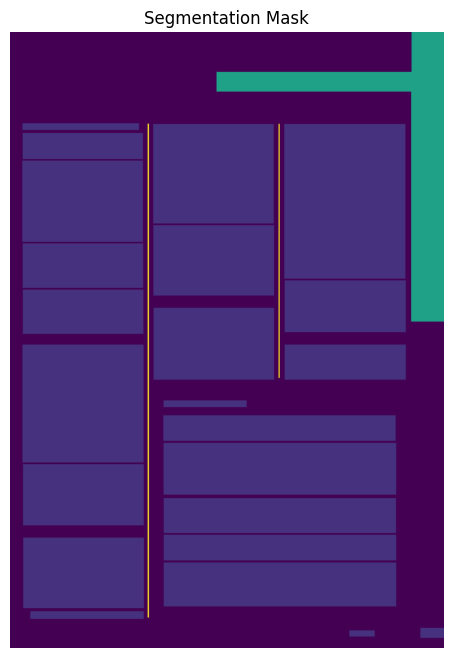

In [33]:
#example
sample_mask_path = glob.glob(
    os.path.join(MASK_DIR, "*.png")
)[6]

sample_mask = np.array(
    Image.open(sample_mask_path)
)

visualize_mask(sample_mask)

In [34]:
#visulaize image and mask together
def visualize_sample(image_path, mask_path):

    image = Image.open(image_path).convert("RGB")

    mask = np.array(
        Image.open(mask_path)
    )

    plt.figure(figsize=(16, 6))

    plt.subplot(1, 2, 1)

    plt.imshow(image)

    plt.title("Original Image")

    plt.axis("off")

    plt.subplot(1, 2, 2)

    plt.imshow(mask)

    plt.title("Ground Truth Mask")

    plt.axis("off")

    plt.show()

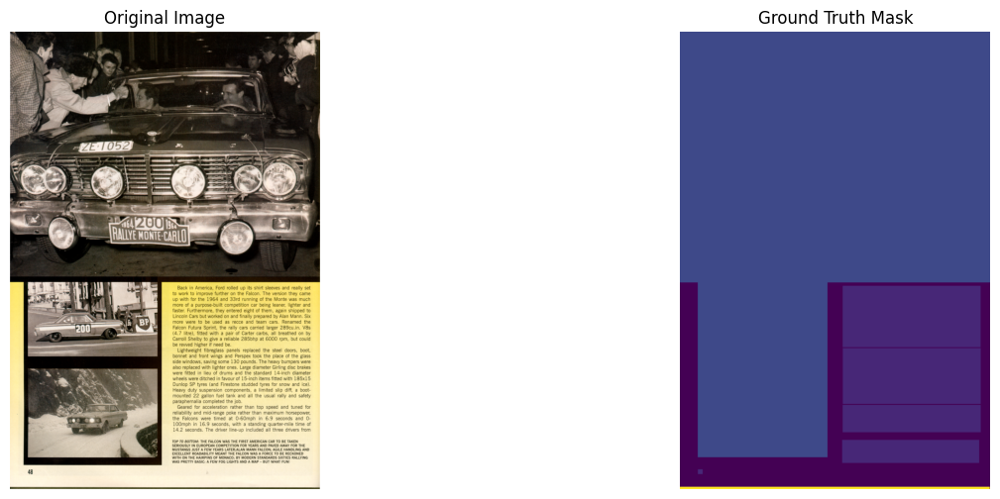

In [35]:
#example
sample_image_path, sample_xml_path = pairs[6]

sample_mask_path = os.path.join(
    MASK_DIR,
    Path(sample_image_path).stem + ".png"
)

visualize_sample(
    sample_image_path,
    sample_mask_path
)

In [36]:
#final dataset
dataset_items = []

for image_path, xml_path in pairs:

    mask_path = os.path.join(
        MASK_DIR,
        Path(image_path).stem + ".png"
    )

    if os.path.exists(mask_path):

        dataset_items.append({
            "image": image_path,
            "xml": xml_path,
            "mask": mask_path
        })

print("Total usable samples:", len(dataset_items))

Total usable samples: 173


In [37]:
#train,test and validation = 70%, 15%, 15%
train_items, temp_items = train_test_split(
    dataset_items,
    test_size=0.30,
    random_state=SEED,
    shuffle=True
)

val_items, test_items = train_test_split(
    temp_items,
    test_size=0.50,
    random_state=SEED,
    shuffle=True
)

print("Training:", len(train_items))
print("Validation:", len(val_items))
print("Testing:", len(test_items))

Training: 121
Validation: 26
Testing: 26


In [38]:
#resizing images
IMAGE_SIZE = 512

BATCH_SIZE = 4

NUM_WORKERS = 2

LEARNING_RATE = 1e-4

NUM_EPOCHS = 3

WEIGHT_DECAY = 1e-5

CHECKPOINT_PATH = "/content/best_unet_prima.pth"

In [39]:
#building the dataset class
class PRImADataset(Dataset):

    def __init__(
        self,
        items,
        image_size=512,
        augment=False
    ):

        self.items = items

        self.image_size = image_size

        self.augment = augment

    def __len__(self):

        return len(self.items)

    def __getitem__(self, index):

        item = self.items[index]

        image = Image.open(
            item["image"]
        ).convert("RGB")

        mask = Image.open(
            item["mask"]
        )

        image = np.array(image)

        mask = np.array(mask)

        # Resize image
        image = cv2.resize(
            image,
            (self.image_size, self.image_size),
            interpolation=cv2.INTER_AREA
        )

        # Resize segmentation mask
        mask = cv2.resize(
            mask,
            (self.image_size, self.image_size),
            interpolation=cv2.INTER_NEAREST
        )

        # Data augmentation
        if self.augment:

            if random.random() < 0.5:

                image = np.fliplr(
                    image
                ).copy()

                mask = np.fliplr(
                    mask
                ).copy()

            if random.random() < 0.5:

                image = np.flipud(
                    image
                ).copy()

                mask = np.flipud(
                    mask
                ).copy()

        # Convert image to float
        image = image.astype(
            np.float32
        ) / 255.0

        # HWC -> CHW
        image = np.transpose(
            image,
            (2, 0, 1)
        )

        image = torch.tensor(
            image,
            dtype=torch.float32
        )

        mask = torch.tensor(
            mask,
            dtype=torch.long
        )

        return image, mask

In [40]:
train_dataset = PRImADataset(
    train_items,
    image_size=IMAGE_SIZE,
    augment=True
)

val_dataset = PRImADataset(
    val_items,
    image_size=IMAGE_SIZE,
    augment=False
)

test_dataset = PRImADataset(
    test_items,
    image_size=IMAGE_SIZE,
    augment=False
)

In [41]:
#dataloader class
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

In [42]:
#verifying dataloader
images, masks = next(iter(train_loader))

print("Images:", images.shape)
print("Masks:", masks.shape)

print("Image dtype:", images.dtype)
print("Mask dtype:", masks.dtype)

print("Image min:", images.min().item())
print("Image max:", images.max().item())

print("Mask classes:", torch.unique(masks))

Images: torch.Size([4, 3, 512, 512])
Masks: torch.Size([4, 512, 512])
Image dtype: torch.float32
Mask dtype: torch.int64
Image min: 0.0
Image max: 1.0
Mask classes: tensor([0, 1, 2, 3, 4, 6, 7, 8, 9])


In [43]:
#UNet Model
class DoubleConv(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels
    ):

        super().__init__()

        self.block = nn.Sequential(

            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),

            nn.BatchNorm2d(
                out_channels
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),

            nn.BatchNorm2d(
                out_channels
            ),

            nn.ReLU(
                inplace=True
            )
        )

    def forward(self, x):

        return self.block(x)

In [44]:
#encoder block of UNet
class DownBlock(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels
    ):

        super().__init__()

        self.block = nn.Sequential(

            nn.MaxPool2d(
                kernel_size=2
            ),

            DoubleConv(
                in_channels,
                out_channels
            )
        )

    def forward(self, x):

        return self.block(x)


In [45]:
#decoder block of UNet
class UpBlock(nn.Module):

    def __init__(
        self,
        in_channels,
        skip_channels,
        out_channels
    ):

        super().__init__()

        self.up = nn.ConvTranspose2d(
            in_channels,
            in_channels // 2,
            kernel_size=2,
            stride=2
        )

        self.conv = DoubleConv(
            in_channels // 2 + skip_channels,
            out_channels
        )

    def forward(
        self,
        x,
        skip
    ):

        x = self.up(x)

        # Handle possible size differences
        diff_y = skip.size(2) - x.size(2)
        diff_x = skip.size(3) - x.size(3)

        x = F.pad(
            x,
            [
                diff_x // 2,
                diff_x - diff_x // 2,
                diff_y // 2,
                diff_y - diff_y // 2
            ]
        )

        x = torch.cat(
            [skip, x],
            dim=1
        )

        return self.conv(x)

In [46]:
#complete U-Net
class UNet(nn.Module):

    def __init__(
        self,
        in_channels=3,
        num_classes=11
    ):

        super().__init__()

        # Encoder
        self.enc1 = DoubleConv(
            in_channels,
            64
        )

        self.enc2 = DownBlock(
            64,
            128
        )

        self.enc3 = DownBlock(
            128,
            256
        )

        self.enc4 = DownBlock(
            256,
            512
        )

        # Bottleneck
        self.bottleneck = DownBlock(
            512,
            1024
        )

        # Decoder
        self.dec4 = UpBlock(
            1024,
            512,
            512
        )

        self.dec3 = UpBlock(
            512,
            256,
            256
        )

        self.dec2 = UpBlock(
            256,
            128,
            128
        )

        self.dec1 = UpBlock(
            128,
            64,
            64
        )

        # Output
        self.output = nn.Conv2d(
            64,
            num_classes,
            kernel_size=1
        )

    def forward(self, x):

        # Encoder
        e1 = self.enc1(x)

        e2 = self.enc2(e1)

        e3 = self.enc3(e2)

        e4 = self.enc4(e3)

        # Bottleneck
        b = self.bottleneck(e4)

        # Decoder
        d4 = self.dec4(
            b,
            e4
        )

        d3 = self.dec3(
            d4,
            e3
        )

        d2 = self.dec2(
            d3,
            e2
        )

        d1 = self.dec1(
            d2,
            e1
        )

        return self.output(d1)


In [47]:
#initializing the model
model = UNet(
    in_channels=3,
    num_classes=NUM_CLASSES
).to(DEVICE)

print(model)

UNet(
  (enc1): DoubleConv(
    (block): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (enc2): DownBlock(
    (block): Sequential(
      (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (1): DoubleConv(
        (block): Sequential(
          (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
          (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (4): 

In [48]:
#model summary
summary(
    model,
    input_size=(
        1,
        3,
        IMAGE_SIZE,
        IMAGE_SIZE
    ),
    col_names=[
        "input_size",
        "output_size",
        "num_params",
        "mult_adds"
    ],
    depth=4
)

Layer (type:depth-idx)                        Input Shape               Output Shape              Param #                   Mult-Adds
UNet                                          [1, 3, 512, 512]          [1, 11, 512, 512]         --                        --
├─DoubleConv: 1-1                             [1, 3, 512, 512]          [1, 64, 512, 512]         --                        --
│    └─Sequential: 2-1                        [1, 3, 512, 512]          [1, 64, 512, 512]         --                        --
│    │    └─Conv2d: 3-1                       [1, 3, 512, 512]          [1, 64, 512, 512]         1,728                     452,984,832
│    │    └─BatchNorm2d: 3-2                  [1, 64, 512, 512]         [1, 64, 512, 512]         128                       128
│    │    └─ReLU: 3-3                         [1, 64, 512, 512]         [1, 64, 512, 512]         --                        --
│    │    └─Conv2d: 3-4                       [1, 64, 512, 512]         [1, 64, 512, 512]     

In [49]:
#Dice loss
class DiceLoss(nn.Module):

    def __init__(
        self,
        smooth=1.0
    ):

        super().__init__()

        self.smooth = smooth

    def forward(
        self,
        logits,
        targets
    ):

        num_classes = logits.shape[1]

        probabilities = torch.softmax(
            logits,
            dim=1
        )

        targets_one_hot = F.one_hot(
            targets,
            num_classes=num_classes
        )

        targets_one_hot = targets_one_hot.permute(
            0,
            3,
            1,
            2
        ).float()

        intersection = (
            probabilities *
            targets_one_hot
        ).sum(
            dim=(0, 2, 3)
        )

        denominator = (
            probabilities.sum(
                dim=(0, 2, 3)
            )
            +
            targets_one_hot.sum(
                dim=(0, 2, 3)
            )
        )

        dice = (
            2.0 * intersection +
            self.smooth
        ) / (
            denominator +
            self.smooth
        )

        return 1.0 - dice.mean()

In [50]:
#combined loss
class CombinedLoss(nn.Module):

    def __init__(
        self,
        ce_weight=0.5,
        dice_weight=0.5
    ):

        super().__init__()

        self.ce = nn.CrossEntropyLoss()

        self.dice = DiceLoss()

        self.ce_weight = ce_weight

        self.dice_weight = dice_weight

    def forward(
        self,
        logits,
        targets
    ):

        ce_loss = self.ce(
            logits,
            targets
        )

        dice_loss = self.dice(
            logits,
            targets
        )

        total_loss = (
            self.ce_weight * ce_loss
            +
            self.dice_weight * dice_loss
        )

        return total_loss

In [51]:
#optimizer
criterion = CombinedLoss(
    ce_weight=0.5,
    dice_weight=0.5
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

In [52]:
#learning rate scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=3,
    min_lr=1e-7
)

In [53]:
"""
Calculates:
Pixel Accuracy
Mean IoU
Mean Dice
Per-class IoU
Per-class Dice
"""

#metric function
def calculate_metrics(
    predictions,
    targets,
    num_classes
):

    predictions = predictions.view(-1)

    targets = targets.view(-1)

    ious = []
    dices = []

    for class_id in range(num_classes):

        pred_class = (
            predictions == class_id
        )

        target_class = (
            targets == class_id
        )

        intersection = (
            pred_class &
            target_class
        ).sum().item()

        union = (
            pred_class |
            target_class
        ).sum().item()

        pred_area = pred_class.sum().item()

        target_area = target_class.sum().item()

        if union == 0:

            iou = float("nan")

        else:

            iou = (
                intersection /
                union
            )

        denominator = (
            pred_area +
            target_area
        )

        if denominator == 0:

            dice = float("nan")

        else:

            dice = (
                2.0 * intersection /
                denominator
            )

        ious.append(iou)

        dices.append(dice)

    valid_ious = [
        x for x in ious
        if not np.isnan(x)
    ]

    valid_dices = [
        x for x in dices
        if not np.isnan(x)
    ]

    accuracy = (
        predictions == targets
    ).float().mean().item()

    mean_iou = np.mean(
        valid_ious
    )

    mean_dice = np.mean(
        valid_dices
    )

    return {
        "accuracy": accuracy,
        "mean_iou": mean_iou,
        "mean_dice": mean_dice,
        "iou_per_class": ious,
        "dice_per_class": dices
    }


In [54]:
#training function
def train_one_epoch(
    model,
    loader,
    optimizer,
    criterion,
    device
):

    model.train()

    running_loss = 0.0

    progress = tqdm(
        loader,
        desc="Training",
        leave=False
    )

    for images, masks in progress:

        images = images.to(
            device,
            non_blocking=True
        )

        masks = masks.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        logits = model(images)

        loss = criterion(
            logits,
            masks
        )

        loss.backward()

        optimizer.step()

        running_loss += (
            loss.item()
            * images.size(0)
        )

        progress.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    epoch_loss = (
        running_loss /
        len(loader.dataset)
    )

    return epoch_loss

In [55]:
#validation function
@torch.no_grad()
def validate(
    model,
    loader,
    criterion,
    device,
    num_classes
):

    model.eval()

    running_loss = 0.0

    all_predictions = []

    all_targets = []

    for images, masks in tqdm(
        loader,
        desc="Validation",
        leave=False
    ):

        images = images.to(
            device,
            non_blocking=True
        )

        masks = masks.to(
            device,
            non_blocking=True
        )

        logits = model(images)

        loss = criterion(
            logits,
            masks
        )

        running_loss += (
            loss.item()
            * images.size(0)
        )

        predictions = torch.argmax(
            logits,
            dim=1
        )

        all_predictions.append(
            predictions.cpu()
        )

        all_targets.append(
            masks.cpu()
        )

    predictions = torch.cat(
        all_predictions
    )

    targets = torch.cat(
        all_targets
    )

    metrics = calculate_metrics(
        predictions,
        targets,
        num_classes
    )

    metrics["loss"] = (
        running_loss /
        len(loader.dataset)
    )

    return metrics

In [56]:
#training loop
history = {
    "train_loss": [],
    "val_loss": [],
    "val_accuracy": [],
    "val_iou": [],
    "val_dice": []
}

best_dice = -1.0

print("Starting training...\n")

for epoch in range(NUM_EPOCHS):

    print(
        f"\nEpoch "
        f"{epoch + 1}/{NUM_EPOCHS}"
    )

    train_loss = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        DEVICE
    )

    val_metrics = validate(
        model,
        val_loader,
        criterion,
        DEVICE,
        NUM_CLASSES
    )

    val_loss = val_metrics["loss"]

    val_accuracy = (
        val_metrics["accuracy"]
    )

    val_iou = (
        val_metrics["mean_iou"]
    )

    val_dice = (
        val_metrics["mean_dice"]
    )

    scheduler.step(
        val_dice
    )

    history["train_loss"].append(
        train_loss
    )

    history["val_loss"].append(
        val_loss
    )

    history["val_accuracy"].append(
        val_accuracy
    )

    history["val_iou"].append(
        val_iou
    )

    history["val_dice"].append(
        val_dice
    )

    print(
        f"Train Loss : {train_loss:.4f}"
    )

    print(
        f"Val Loss   : {val_loss:.4f}"
    )

    print(
        f"Val Acc    : {val_accuracy:.4f}"
    )

    print(
        f"Val IoU    : {val_iou:.4f}"
    )

    print(
        f"Val Dice   : {val_dice:.4f}"
    )

    current_lr = optimizer.param_groups[0]["lr"]

    print(
        f"LR         : {current_lr:.7f}"
    )

    # Save best model
    if val_dice > best_dice:

        best_dice = val_dice

        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_dice": val_dice,
                "val_iou": val_iou,
                "class_names": CLASS_NAMES,
                "image_size": IMAGE_SIZE
            },
            CHECKPOINT_PATH
        )

        print(
            f"Best model saved: "
            f"{CHECKPOINT_PATH}"
        )

Starting training...


Epoch 1/3


Training:   0%|          | 0/31 [00:00<?, ?it/s]

Validation:   0%|          | 0/7 [00:00<?, ?it/s]

Train Loss : 1.2750
Val Loss   : 1.5265
Val Acc    : 0.4494
Val IoU    : 0.0787
Val Dice   : 0.1104
LR         : 0.0001000
Best model saved: /content/best_unet_prima.pth

Epoch 2/3


Training:   0%|          | 0/31 [00:00<?, ?it/s]

...

Train Loss : 1.0324
Val Loss   : 0.9898
Val Acc    : 0.8198
Val IoU    : 0.1907
Val Dice   : 0.2239
LR         : 0.0001000
Best model saved: /content/best_unet_prima.pth

Epoch 3/3


Training:   0%|          | 0/31 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7bad391e2520>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7bad391e2520>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del

Validation:   0%|          | 0/7 [00:00<?, ?it/s]

Train Loss : 0.9668
Val Loss   : 0.9183
Val Acc    : 0.8245
Val IoU    : 0.1904
Val Dice   : 0.2233
LR         : 0.0001000


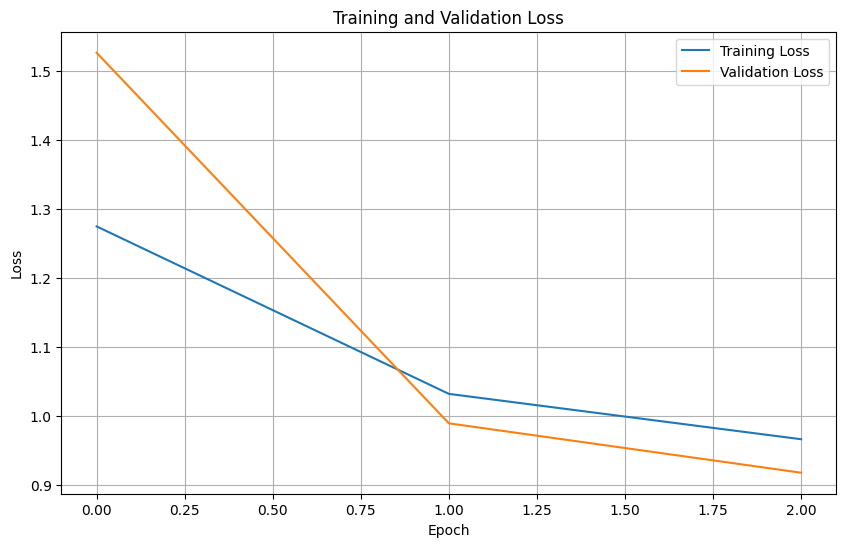

In [57]:
#plot training curves
plt.figure(figsize=(10, 6))

plt.plot(
    history["train_loss"],
    label="Training Loss"
)

plt.plot(
    history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training and Validation Loss")

plt.legend()

plt.grid()

plt.show()

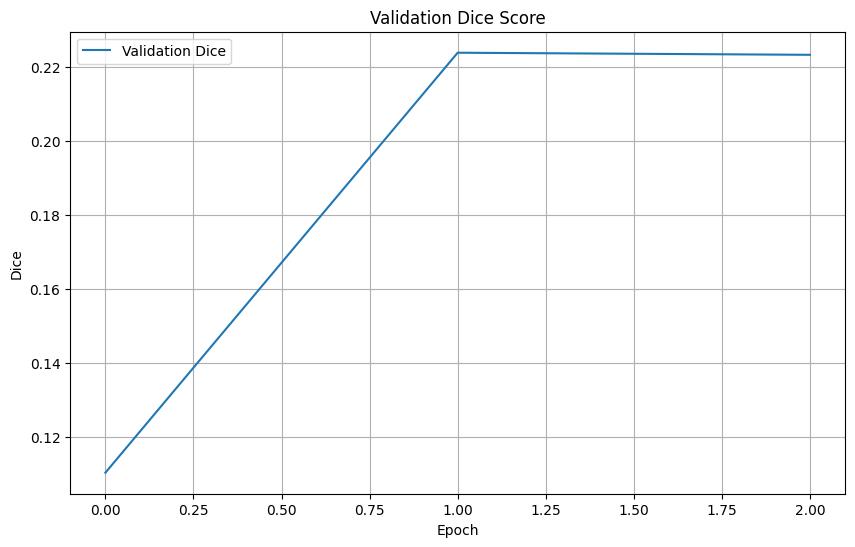

In [58]:
#plot validation dice
plt.figure(figsize=(10, 6))

plt.plot(
    history["val_dice"],
    label="Validation Dice"
)

plt.xlabel("Epoch")

plt.ylabel("Dice")

plt.title("Validation Dice Score")

plt.legend()

plt.grid()

plt.show()

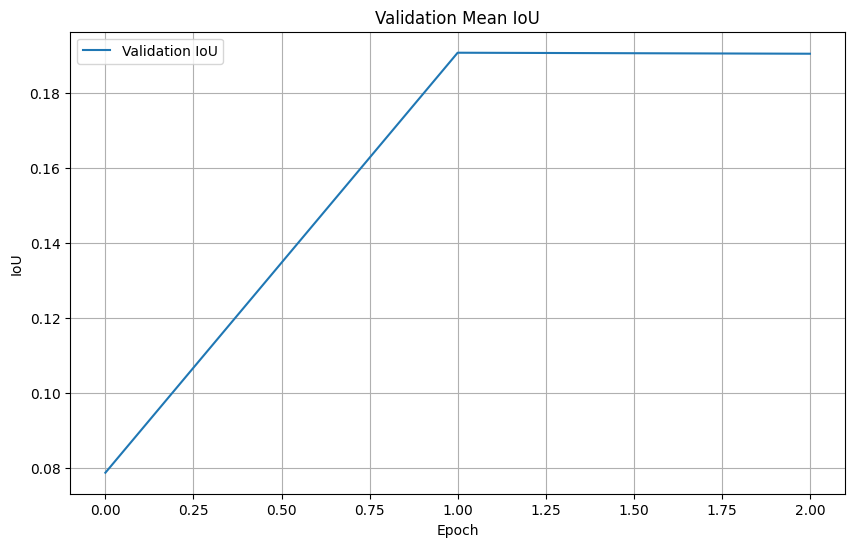

In [59]:
#plot validation IOU
plt.figure(figsize=(10, 6))

plt.plot(
    history["val_iou"],
    label="Validation IoU"
)

plt.xlabel("Epoch")

plt.ylabel("IoU")

plt.title("Validation Mean IoU")

plt.legend()

plt.grid()

plt.show()

In [60]:
import pandas as pd

history_df = pd.DataFrame(
    history
)

HISTORY_PATH = os.path.join(
    DATASET_ROOT,
    "unet_training_history.csv"
)

history_df.to_csv(
    HISTORY_PATH,
    index=False
)

print(
    "Training history saved:",
    HISTORY_PATH
)

#load the best U-Net
checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=DEVICE,
    weights_only=False
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

print(
    "Loaded best model from epoch:",
    checkpoint["epoch"]
)

print(
    "Best validation Dice:",
    checkpoint["val_dice"]
)


Training history saved: /content/PRImA_project/PRImA_Layout_Analysis_Dataset/unet_training_history.csv
Loaded best model from epoch: 2
Best validation Dice: 0.2238745581459079


In [61]:
#evaluation on test set
test_metrics = validate(
    model,
    test_loader,
    criterion,
    DEVICE,
    NUM_CLASSES
)

print("\n========== TEST RESULTS ==========")

print(
    f"Test Loss      : "
    f"{test_metrics['loss']:.4f}"
)

print(
    f"Pixel Accuracy : "
    f"{test_metrics['accuracy']:.4f}"
)

print(
    f"Mean IoU       : "
    f"{test_metrics['mean_iou']:.4f}"
)

print(
    f"Mean Dice      : "
    f"{test_metrics['mean_dice']:.4f}"
)

Validation:   0%|          | 0/7 [00:00<?, ?it/s]


========== TEST RESULTS ==========
Test Loss      : 0.9304
Pixel Accuracy : 0.8519
Mean IoU       : 0.2117
Mean Dice      : 0.2419


In [62]:
#per class results
print("\n========== PER-CLASS RESULTS ==========")

for class_id, class_name in enumerate(
    CLASS_NAMES
):

    iou = test_metrics[
        "iou_per_class"
    ][class_id]

    dice = test_metrics[
        "dice_per_class"
    ][class_id]

    print(
        f"{class_name:15s} "
        f"IoU={iou:.4f} "
        f"Dice={dice:.4f}"
    )


========== PER-CLASS RESULTS ==========
background      IoU=0.7588 Dice=0.8629
text            IoU=0.7840 Dice=0.8789
image           IoU=0.7561 Dice=0.8611
line_drawing    IoU=0.0297 Dice=0.0577
graphic         IoU=0.0000 Dice=0.0000
table           IoU=0.0002 Dice=0.0004
chart           IoU=0.0000 Dice=0.0000
separator       IoU=0.0000 Dice=0.0000
maths           IoU=0.0000 Dice=0.0000
noise           IoU=0.0000 Dice=0.0000
frame           IoU=0.0000 Dice=0.0000


In [63]:
#prediction function
@torch.no_grad()
def predict_image(
    model,
    image_path,
    image_size,
    device
):

    model.eval()

    original = Image.open(
        image_path
    ).convert("RGB")

    original_np = np.array(
        original
    )

    resized = cv2.resize(
        original_np,
        (image_size, image_size),
        interpolation=cv2.INTER_AREA
    )

    image = (
        resized.astype(
            np.float32
        ) / 255.0
    )

    image = np.transpose(
        image,
        (2, 0, 1)
    )

    tensor = torch.tensor(
        image,
        dtype=torch.float32
    ).unsqueeze(0)

    tensor = tensor.to(device)

    logits = model(tensor)

    prediction = torch.argmax(
        logits,
        dim=1
    )

    prediction = prediction[
        0
    ].cpu().numpy()

    return original_np, prediction

In [64]:
#inference
test_image_path = test_items[0]["image"]

original, prediction = predict_image(
    model,
    test_image_path,
    IMAGE_SIZE,
    DEVICE
)

print("Prediction shape:", prediction.shape)
print(
    "Predicted classes:",
    np.unique(prediction)
)

Prediction shape: (512, 512)
Predicted classes: [0 1 2 3 4 5 7]


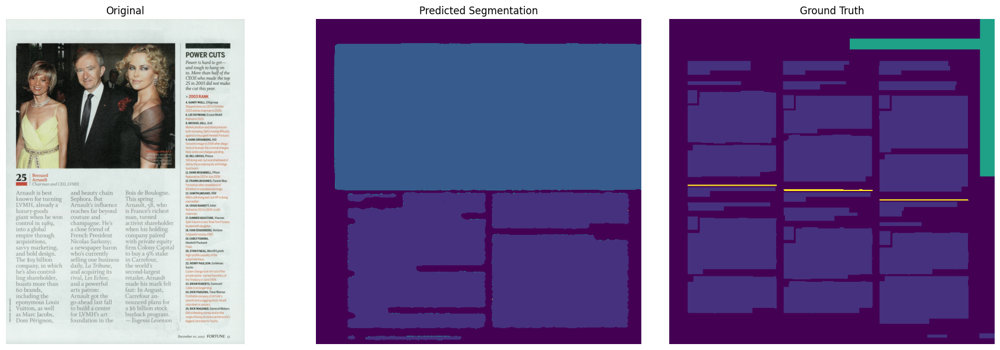

In [81]:
#prediction visualization
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)

plt.imshow(original)

plt.title("Original")

plt.axis("off")


plt.subplot(1, 3, 2)

plt.imshow(prediction)

plt.title("Predicted Segmentation")

plt.axis("off")


ground_truth = np.array(
    Image.open(
        test_items[0]["mask"]
    )
)

ground_truth = cv2.resize(
    ground_truth,
    (IMAGE_SIZE, IMAGE_SIZE),
    interpolation=cv2.INTER_NEAREST
)

plt.subplot(1, 3, 3)

plt.imshow(ground_truth)

plt.title("Ground Truth")

plt.axis("off")

plt.tight_layout()

plt.show()

In [66]:
#comparision and overlay of prediction with original image
def create_segmentation_overlay(
    image,
    mask,
    alpha=0.45
):

    image = image.astype(
        np.uint8
    )

    overlay = np.zeros_like(
        image
    )

    # Generate a deterministic color for each class
    rng = np.random.default_rng(42)

    colors = rng.integers(
        0,
        256,
        size=(NUM_CLASSES, 3),
        dtype=np.uint8
    )

    colors[0] = [0, 0, 0]

    for class_id in range(
        1,
        NUM_CLASSES
    ):

        overlay[
            mask == class_id
        ] = colors[class_id]

    result = cv2.addWeighted(
        image,
        1 - alpha,
        overlay,
        alpha,
        0
    )

    return result

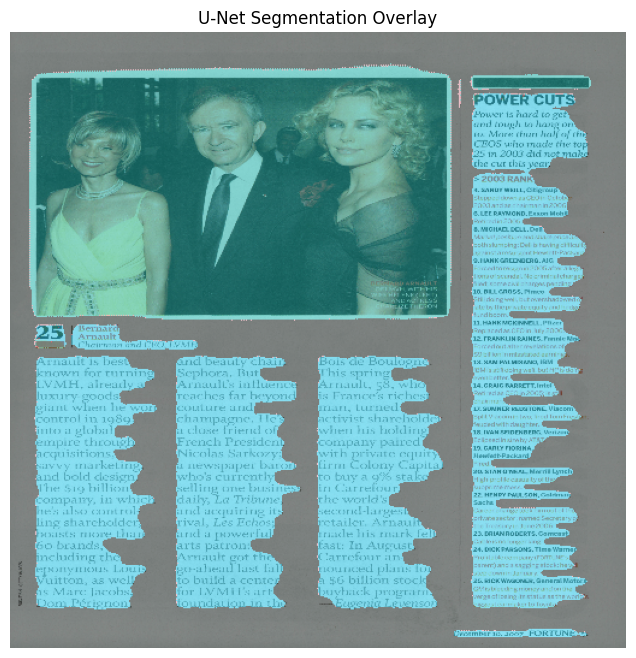

In [67]:
#overlay display
overlay = create_segmentation_overlay(
    cv2.resize(
        original,
        (IMAGE_SIZE, IMAGE_SIZE)
    ),
    prediction
)

plt.figure(figsize=(12, 8))

plt.imshow(overlay)

plt.title(
    "U-Net Segmentation Overlay"
)

plt.axis("off")

plt.show()

In [68]:
#generate proper class legend
def show_class_legend():

    fig, ax = plt.subplots(
        figsize=(8, 6)
    )

    rng = np.random.default_rng(42)

    colors = rng.integers(
        0,
        256,
        size=(NUM_CLASSES, 3),
        dtype=np.uint8
    )

    colors[0] = [0, 0, 0]

    for class_id, class_name in enumerate(
        CLASS_NAMES
    ):

        ax.scatter(
            [],
            [],
            color=colors[class_id] / 255.0,
            label=f"{class_id}: {class_name}"
        )

    ax.legend(
        loc="center",
        frameon=False
    )

    ax.axis("off")

    plt.show()

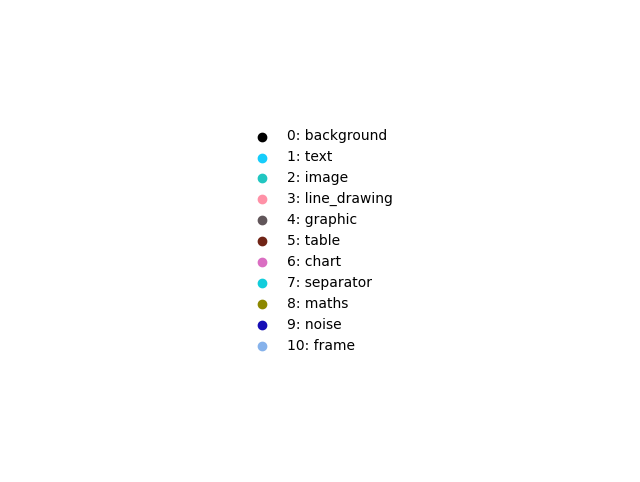

In [69]:
show_class_legend()

In [70]:
#save predictions
PREDICTION_DIR = os.path.join(
    DATASET_ROOT,
    "predictions"
)

os.makedirs(
    PREDICTION_DIR,
    exist_ok=True
)

In [71]:
#save masks for the entire test set
model.eval()

for item in tqdm(
    test_items,
    desc="Generating test predictions"
):

    image = Image.open(
        item["image"]
    ).convert("RGB")

    image_np = np.array(
        image
    )

    resized = cv2.resize(
        image_np,
        (IMAGE_SIZE, IMAGE_SIZE),
        interpolation=cv2.INTER_AREA
    )

    tensor = (
        resized.astype(
            np.float32
        ) / 255.0
    )

    tensor = np.transpose(
        tensor,
        (2, 0, 1)
    )

    tensor = torch.tensor(
        tensor,
        dtype=torch.float32
    ).unsqueeze(0)

    tensor = tensor.to(DEVICE)

    with torch.no_grad():

        logits = model(tensor)

        prediction = torch.argmax(
            logits,
            dim=1
        )[0].cpu().numpy()

    output_path = os.path.join(
        PREDICTION_DIR,
        Path(item["image"]).stem + ".png"
    )

    Image.fromarray(
        prediction.astype(np.uint8)
    ).save(
        output_path
    )

print(
    "Predictions saved to:",
    PREDICTION_DIR
)

Generating test predictions:   0%|          | 0/26 [00:00<?, ?it/s]

Predictions saved to: /content/PRImA_project/PRImA_Layout_Analysis_Dataset/predictions


In [72]:
#save the final model
FINAL_MODEL_PATH = os.path.join(
    DATASET_ROOT,
    "prima_unet_final.pth"
)

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "class_names": CLASS_NAMES,
        "class_to_id": CLASS_TO_ID,
        "image_size": IMAGE_SIZE,
        "num_classes": NUM_CLASSES
    },
    FINAL_MODEL_PATH
)

print(
    "Final model saved to:",
    FINAL_MODEL_PATH
)

Final model saved to: /content/PRImA_project/PRImA_Layout_Analysis_Dataset/prima_unet_final.pth


In [73]:
#visualize multiple test predictions
def visualize_predictions(
    model,
    items,
    num_samples=5
):

    num_samples = min(
        num_samples,
        len(items)
    )

    selected_items = random.sample(
        items,
        num_samples
    )

    for item in selected_items:

        original, prediction = predict_image(
            model,
            item["image"],
            IMAGE_SIZE,
            DEVICE
        )

        ground_truth = np.array(
            Image.open(
                item["mask"]
            )
        )

        ground_truth = cv2.resize(
            ground_truth,
            (IMAGE_SIZE, IMAGE_SIZE),
            interpolation=cv2.INTER_NEAREST
        )

        resized_original = cv2.resize(
            original,
            (IMAGE_SIZE, IMAGE_SIZE)
        )

        overlay = create_segmentation_overlay(
            resized_original,
            prediction
        )

        plt.figure(figsize=(18, 6))

        plt.subplot(1, 3, 1)

        plt.imshow(resized_original)

        plt.title("Original")

        plt.axis("off")

        plt.subplot(1, 3, 2)

        plt.imshow(ground_truth)

        plt.title("Ground Truth")

        plt.axis("off")

        plt.subplot(1, 3, 3)

        plt.imshow(overlay)

        plt.title("U-Net Prediction")

        plt.axis("off")

        plt.tight_layout()

        plt.show()

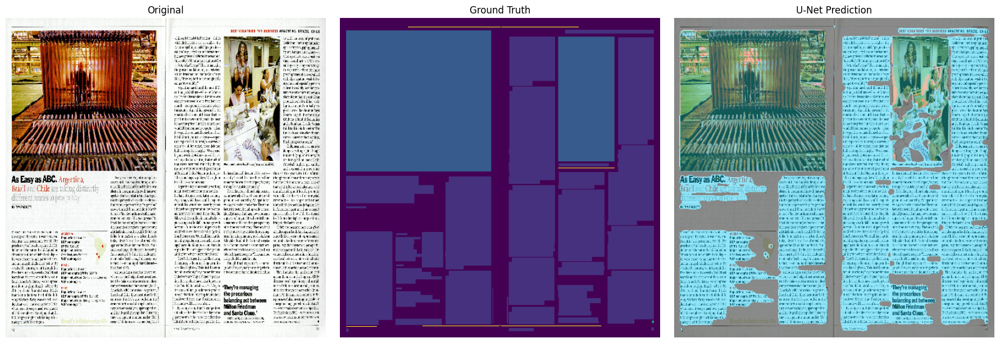

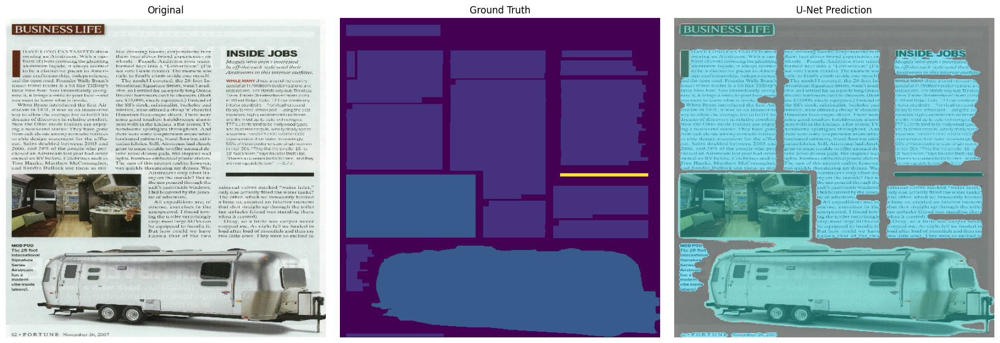

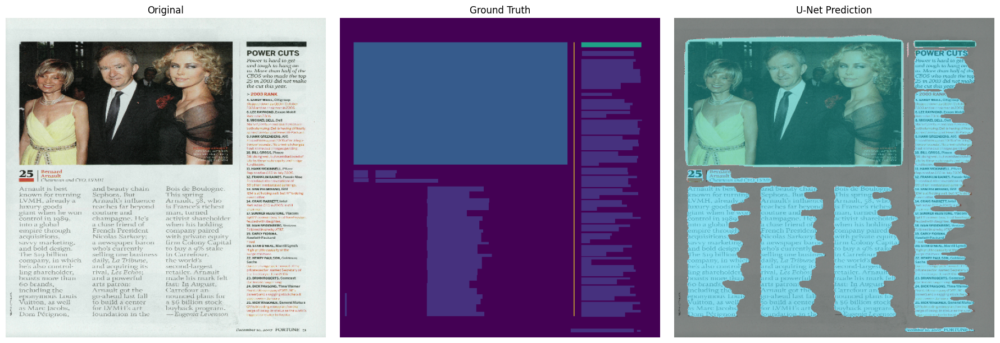

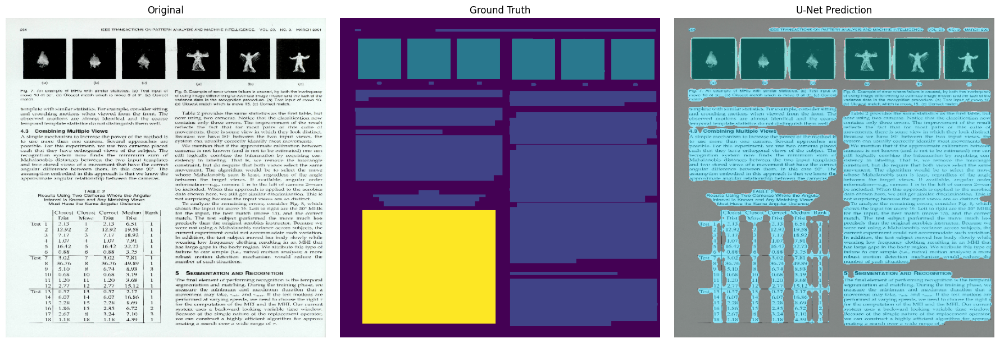

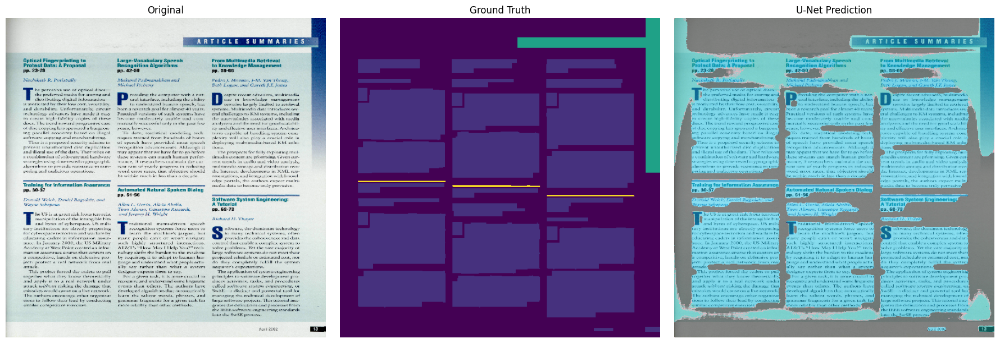

In [74]:
visualize_predictions(
    model,
    test_items,
    num_samples=5
)

In [75]:
#evaluation table
results = []

for class_id, class_name in enumerate(
    CLASS_NAMES
):

    results.append({
        "Class": class_name,
        "IoU": test_metrics[
            "iou_per_class"
        ][class_id],
        "Dice": test_metrics[
            "dice_per_class"
        ][class_id]
    })

results_df = pd.DataFrame(
    results
)

results_df

,Class,IoU,Dice
0,background,0.758817,0.862872
1,text,0.784004,0.878927
2,image,0.756066,0.861091
3,line_drawing,0.029720,0.057725
4,graphic,0.000000,0.000000
5,table,0.000188,0.000377
6,chart,0.000000,0.000000
7,separator,0.000000,0.000000
8,maths,0.000000,0.000000
9,noise,0.000000,0.000000


In [76]:
#load the model later
loaded_model = UNet(
    in_channels=3,
    num_classes=NUM_CLASSES
).to(DEVICE)

checkpoint = torch.load(
    FINAL_MODEL_PATH,
    map_location=DEVICE
)

loaded_model.load_state_dict(
    checkpoint["model_state_dict"]
)

loaded_model.eval()

print("U-Net loaded successfully.")

U-Net loaded successfully.


In [77]:
#save training history
history_df = pd.DataFrame(
    history
)

HISTORY_PATH = os.path.join(
    DATASET_ROOT,
    "unet_training_history.csv"
)

history_df.to_csv(
    HISTORY_PATH,
    index=False
)

print(
    "Training history saved:",
    HISTORY_PATH
)

Training history saved: /content/PRImA_project/PRImA_Layout_Analysis_Dataset/unet_training_history.csv


In [78]:
#save evaluation results
RESULTS_PATH = os.path.join(
    DATASET_ROOT,
    "unet_test_results.csv"
)

results_df.to_csv(
    RESULTS_PATH,
    index=False
)

print(
    "Results saved:",
    RESULTS_PATH
)

Results saved: /content/PRImA_project/PRImA_Layout_Analysis_Dataset/unet_test_results.csv
